## 9a - Download AlphaEarth Satellite Embeddings for Amsterdam

This script:
- Authenticates with Google Earth Engine
- Exports the AlphaEarth annual satellite embedding image for Amsterdam as a GeoTIFF
- Merges tile files (EE splits large exports into multiple tiles)
- Once downloaded, computes **zonal statistics per buurt** locally (mean, median, min, max)
- Additionally re-aggregates the raster over the **street-view sampling support** (the
  panorama point locations from notebook 3) as `road_point` and `road_buffer` variants, so
  notebook 9b can test whether AlphaEarth's weaker fit is partly a sampling artefact
- Saves all aggregations to pickle files for downstream experiments

The [AlphaEarth Foundations Satellite Embedding dataset](https://developers.google.com/earth-engine/datasets/catalog/GOOGLE_SATELLITE_EMBEDDING_V1_ANNUAL) is produced by Google and Google DeepMind.
It provides global, 10m-resolution, 64-dimensional embeddings derived from optical, radar, and LiDAR satellite data.
We use these aerial/satellite-derived embeddings as an alternative to the street-level CLIP embeddings
used in earlier scripts, to compare how well urban form visible from above predicts deprivation
versus visual cues at street level.

**Why download the full raster?** Rather than computing stats on Earth Engine's servers
(which consumes EE credits each time), we download the raw GeoTIFF once and compute zonal
statistics locally. This lets us experiment with different aggregation methods without
hitting Earth Engine again.

> **⚠️ MANUAL STEPS REQUIRED (you must do these yourself):**
> 1. **Google Earth Engine authentication + Cloud project** — run `earthengine authenticate` and set
>    your own Cloud project ID in the `ee.Initialize(...)` cell below.
> 2. **Manual GeoTIFF download** — after the EE export task completes, download all tile files from
>    your Google Drive and place them in the tiles directory (see the merge cell).
>
> The AlphaEarth dataset is global, so apart from these manual steps the processing is a standard
> zonal aggregation of the embedding raster onto the Amsterdam buurten.

**Prerequisites**: `pip install earthengine-api rasterio rasterstats`

### Dependencies
**Prerequisites:** None for the whole-buurt zonal stats — independent branch (requires Google
Earth Engine authentication and a Cloud project). The **road-following variants** additionally
require the panorama H5 from notebooks 1–2.

**Inputs:**
- Amsterdam buurt boundaries (via `amsterdam_data.get_amsterdam_buurten()`)
- Google Earth Engine AlphaEarth annual composite (accessed via `ee` API)
- GeoTIFF tile files downloaded manually from Google Drive after EE export
- `data/processed/street_data.h5` — panorama point locations (road-following variants only)

**Outputs:**
- `data/processed/alphaearth_amsterdam_2023.tif.gz` — merged and compressed 64-band GeoTIFF
- `data/processed/per_buurt_embedding_summaries/alphaearth_embeddings.pkl` — per-buurt satellite embedding summaries (whole-buurt zonal: mean, median, min, max)
- `data/processed/per_buurt_embedding_summaries/alphaearth_embeddings_road_point.pkl` — per-buurt summaries from the single pixel under each panorama point
- `data/processed/per_buurt_embedding_summaries/alphaearth_embeddings_road_buffer.pkl` — per-buurt summaries from pixels within `ROAD_BUFFER_M` of each panorama point
- `outputs/9a-comparing_embeddings.png` — pixel-level vs buurt-level PCA false-colour (whole-buurt zonal)
- `outputs/9a-roadsampled_embeddings.png` — per-point vs buurt-level PCA false-colour (road-following sample)

**Used by:** Script 9b

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import os
import glob
import time
import gzip
import shutil

from sklearn.decomposition import PCA
from rasterio.plot import show as rioshow

import ee
import rasterio
from rasterio.merge import merge as rasterio_merge
from rasterstats import zonal_stats

In [2]:
from directory_filepaths import *
from amsterdam_data import get_amsterdam_buurten

### Configuration

In [3]:
# --- Configuration ---
YEAR = 2023            # Annual composite year (dataset covers 2017-2024)
EMBEDDING_DIM = 64     # AlphaEarth embedding dimensionality
BAND_NAMES = [f"A{i:02d}" for i in range(EMBEDDING_DIM)]

# All aggregation statistics to compute per buurt.
# These are all computed in a single pass over the raster and saved to the pickle.
AGGREGATIONS = ['mean', 'median', 'min', 'max']

# Google Drive folder where Earth Engine will export the GeoTIFF
DRIVE_FOLDER = 'EarthEngine_exports'

# Local paths
# Earth Engine may split large exports into multiple tile files.
# Place all downloaded tiles (alphaearth_amsterdam_2023*.tif) into this directory:
TILES_DIR = os.path.join(data_dir, "alphaearth_tiles")
# The merged single GeoTIFF (stored gzipped to save disk space):
GEOTIFF_FILE = os.path.join(data_dir, f"alphaearth_amsterdam_{YEAR}.tif")
GEOTIFF_FILE_GZ = GEOTIFF_FILE + ".gz"

cache_dir = os.path.join(data_dir, "per_buurt_embedding_summaries")
os.makedirs(cache_dir, exist_ok=True)
CACHE_FILE = os.path.join(cache_dir, "alphaearth_embeddings.pkl")

print(f"Tiles directory: {TILES_DIR}")
print(f"Merged GeoTIFF:  {GEOTIFF_FILE_GZ}")
print(f"Aggregations:    {AGGREGATIONS}")

Tiles directory: ../data/processed/alphaearth_tiles
Merged GeoTIFF:  ../data/processed/alphaearth_amsterdam_2023.tif.gz
Aggregations:    ['mean', 'median', 'min', 'max']


### Authenticate with Google Earth Engine

Run `earthengine authenticate` in your terminal (or `ee.Authenticate()` here) once to set up credentials.
You need a Google Cloud project with the Earth Engine API enabled.
Replace the project ID below with your own.

See: https://developers.google.com/earth-engine/guides/python_install

In [4]:
# ee.Authenticate()  # Uncomment if you haven't authenticated via the terminal
# >>> YOU MUST REPLACE the project ID below with your own GEE Cloud project ID <<<
ee.Initialize(project='street-view-gentrification')

### Load Amsterdam buurt polygons

Amsterdam buurten: 839


<Axes: >

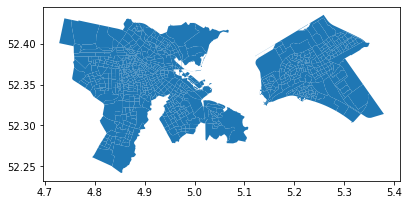

In [5]:
# Load Amsterdam buurt boundaries (Earth Engine and the GeoTIFF use WGS84)
ams_buurten = get_amsterdam_buurten().to_crs(epsg=4326)
print(f"Amsterdam buurten: {len(ams_buurten)}")
ams_buurten.plot()

### Export GeoTIFF from Earth Engine

This cell submits an export task to Earth Engine. The GeoTIFF (64 bands, 10m resolution)
is saved to your Google Drive. The cell polls until the task completes.

**Important**: Earth Engine may split large exports into multiple tile files
(e.g. `alphaearth_gm_2023-0000000000-0000000000.tif`, etc.).
Download **all** tile files from Google Drive and place them in the tiles directory
shown above. The next cell will merge them into a single GeoTIFF.

If the merged GeoTIFF already exists on disk, this cell will skip the export.

In [6]:
if os.path.exists(GEOTIFF_FILE) or os.path.exists(GEOTIFF_FILE_GZ):
    print(f"Merged GeoTIFF already exists — skipping export.")
    print("Delete the file and re-run this cell to re-export.")
else:
    # Load the AlphaEarth annual composite for the chosen year
    dataset = ee.ImageCollection('GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL')
    image = dataset.filterDate(f'{YEAR}-01-01', f'{YEAR+1}-01-01').mosaic()

    # Compute bounding box of Amsterdam (with a small buffer)
    bounds = ams_buurten.total_bounds  # [minx, miny, maxx, maxy]
    buffer_deg = 0.01  # ~1km buffer to avoid edge clipping
    region = ee.Geometry.Rectangle([
        bounds[0] - buffer_deg, bounds[1] - buffer_deg,
        bounds[2] + buffer_deg, bounds[3] + buffer_deg
    ])

    print(f"Bounding box: {bounds}")
    print(f"Exporting {EMBEDDING_DIM}-band GeoTIFF at 10m resolution to Drive folder '{DRIVE_FOLDER}'...")

    # Submit export task — this runs on EE servers and saves tile file(s) to Google Drive.
    # Large exports are automatically split into multiple tiles.
    task = ee.batch.Export.image.toDrive(
        image=image.select(BAND_NAMES),
        description=f'alphaearth_amsterdam_{YEAR}',
        folder=DRIVE_FOLDER,
        fileNamePrefix=f'alphaearth_amsterdam_{YEAR}',
        region=region,
        scale=10,
        crs='EPSG:4326',
        maxPixels=1e9,
        fileFormat='GeoTIFF'
    )
    task.start()
    print(f"Export task started (ID: {task.id})")

    # Poll until the task completes (prints a new line each time so it's visible in Jupyter)
    while task.active():
        status = task.status()
        print(f"  Status: {status['state']}...", flush=True)
        time.sleep(30)

    status = task.status()
    print(f"\nTask finished with state: {status['state']}")
    if status['state'] == 'COMPLETED':
        print(f"\nDownload all tile files from Google Drive (folder: {DRIVE_FOLDER})")
        print(f"and place them in: {TILES_DIR}")
    else:
        print(f"Error: {status.get('error_message', 'unknown error')}")

Merged GeoTIFF already exists — skipping export.
Delete the file and re-run this cell to re-export.


### Merge tile files into a single GeoTIFF (_this might take some time_)

Earth Engine splits large exports into multiple tiles. This cell finds all tile files
in the tiles directory, merges them into one GeoTIFF, and saves it.
If the merged file already exists, this step is skipped.

In [7]:
if os.path.exists(GEOTIFF_FILE_GZ):
    print(f"Compressed GeoTIFF already exists at {GEOTIFF_FILE_GZ} — skipping merge.")
elif os.path.exists(GEOTIFF_FILE):
    print(f"Uncompressed GeoTIFF found at {GEOTIFF_FILE} — compressing...")
    with open(GEOTIFF_FILE, 'rb') as f_in, gzip.open(GEOTIFF_FILE_GZ, 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)
    os.remove(GEOTIFF_FILE)
    print(f"Compressed → {GEOTIFF_FILE_GZ}")
else:
    # Find all tile files matching the export name pattern
    tile_pattern = os.path.join(TILES_DIR, f"alphaearth_amsterdam_{YEAR}*.tif")
    tile_files = sorted(glob.glob(tile_pattern))

    assert len(tile_files) > 0, (
        f"No tile files found matching {tile_pattern}.\n"
        f"Download all tiles from Google Drive (folder: {DRIVE_FOLDER}) "
        f"and place them in: {TILES_DIR}"
    )

    print(f"Found {len(tile_files)} tile files in {TILES_DIR}")
    for f in tile_files:
        print(f"  {os.path.basename(f)}")

    if len(tile_files) == 1:
        # Single file — just copy/rename it
        shutil.copy2(tile_files[0], GEOTIFF_FILE)
        print(f"\nSingle tile — copied to {GEOTIFF_FILE}")
    else:
        # Open all tiles and merge into one raster
        src_files = [rasterio.open(f) for f in tile_files]
        print(f"Merging {len(src_files)} tile files.")
        merged_data, merged_transform = rasterio_merge(src_files)

        # Write the merged raster with the same metadata as the first tile
        meta = src_files[0].meta.copy()
        meta.update({
            'height': merged_data.shape[1],
            'width': merged_data.shape[2],
            'transform': merged_transform,
        })

        with rasterio.open(GEOTIFF_FILE, 'w', **meta) as dst:
            dst.write(merged_data)

        # Close all source files
        for src in src_files:
            src.close()

        print(f"\nMerged {len(tile_files)} tiles → {GEOTIFF_FILE}")
        print(f"Shape: {merged_data.shape[0]} bands × {merged_data.shape[1]} × {merged_data.shape[2]} pixels")

    # Gzip the merged GeoTIFF to save disk space
    print(f"Compressing {GEOTIFF_FILE}...")
    with open(GEOTIFF_FILE, 'rb') as f_in, gzip.open(GEOTIFF_FILE_GZ, 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)
    os.remove(GEOTIFF_FILE)
    print(f"Compressed → {GEOTIFF_FILE_GZ}")

Compressed GeoTIFF already exists at ../data/processed/alphaearth_amsterdam_2023.tif.gz — skipping merge.


Quick visual check: reduce 64 bands to 3 PCs and display as false-colour RGB,
with LSOA boundaries overlaid to verify spatial alignment.

### Decompress GeoTIFF for local processing

The GeoTIFF is stored gzipped on disk to save space (~19 GB uncompressed).
This cell decompresses it to a temporary `.tif` file so rasterio can read it.
The uncompressed file is cleaned up at the end of the notebook.

In [8]:
# Decompress the gzipped GeoTIFF so rasterio can read it.
# If the uncompressed file already exists (e.g. from a previous partial run), skip.
if os.path.exists(GEOTIFF_FILE):
    print(f"Uncompressed GeoTIFF already present at {GEOTIFF_FILE}")
elif os.path.exists(GEOTIFF_FILE_GZ):
    print(f"Decompressing {GEOTIFF_FILE_GZ}...")
    t0 = time.time()
    with gzip.open(GEOTIFF_FILE_GZ, 'rb') as f_in, open(GEOTIFF_FILE, 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)
    print(f"Decompressed → {GEOTIFF_FILE} ({time.time() - t0:.0f}s)")
else:
    raise FileNotFoundError(
        f"Neither {GEOTIFF_FILE} nor {GEOTIFF_FILE_GZ} found.\n"
        f"Run the export and merge cells above first."
    )

Decompressing ../data/processed/alphaearth_amsterdam_2023.tif.gz...


Decompressed → ../data/processed/alphaearth_amsterdam_2023.tif (10s)


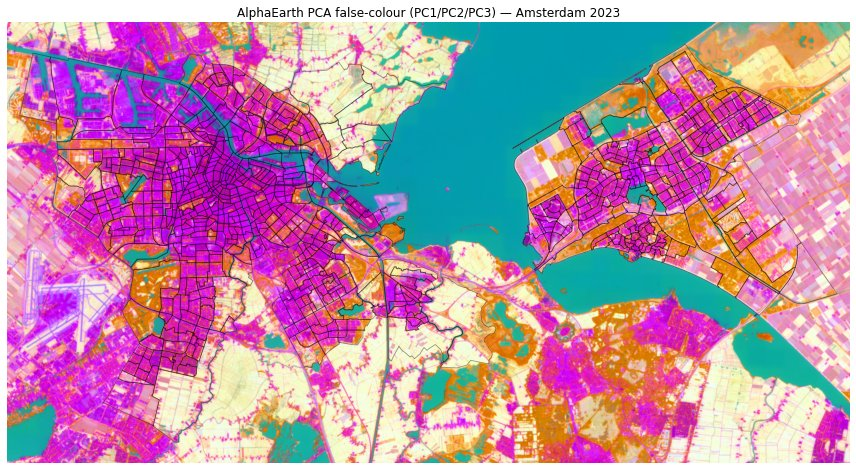

In [9]:

with rasterio.open(GEOTIFF_FILE) as src:
    # Read all 64 bands → shape (bands, height, width)
    data = src.read()
    extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

# Reshape to (n_pixels, 64) for PCA, masking out nodata pixels
bands, h, w = data.shape
flat = data.reshape(bands, -1).T  # (n_pixels, 64)
valid = np.all(np.isfinite(flat), axis=1)

# Run PCA on valid pixels only
pca_rgb = PCA(n_components=3)
pca_rgb.fit(flat[valid])
transformed = np.full((h * w, 3), np.nan)
transformed[valid] = pca_rgb.transform(flat[valid])
rgb = transformed.reshape(h, w, 3)

# Normalise each channel to 0–1 for display
for ch in range(3):
    band = rgb[:, :, ch]
    vmin, vmax = np.nanpercentile(band, [2, 98])
    rgb[:, :, ch] = np.clip((band - vmin) / (vmax - vmin), 0, 1)

# Replace NaN pixels with white
rgb = np.nan_to_num(rgb, nan=1.0)

fig, ax = plt.subplots(figsize=(12, 10))
ax.imshow(rgb, extent=extent, origin='upper')
ams_buurten.boundary.plot(ax=ax, linewidth=0.8, color='black', alpha=0.4)
ax.set_title(f'AlphaEarth PCA false-colour (PC1/PC2/PC3) — Amsterdam {YEAR}')
ax.set_axis_off()
plt.tight_layout()
show_jpeg()

### Compute zonal statistics per LSOA

Now that we have the merged GeoTIFF on disk, compute per-LSOA embeddings by aggregating
all 10m pixels within each LSOA polygon. We compute **all** aggregation statistics
(mean, median, min, max) in a single pass so they're available for downstream experiments
without re-running.

This cell only requires the local GeoTIFF — no Earth Engine calls.

In [10]:
assert os.path.exists(GEOTIFF_FILE), (
    f"Uncompressed GeoTIFF not found at {GEOTIFF_FILE}.\n"
    f"Run the decompress cell above first."
)

# Quick look at the raster metadata
with rasterio.open(GEOTIFF_FILE) as src:
    print(f"Bands:      {src.count}")
    print(f"Size:       {src.width} x {src.height} pixels")
    print(f"CRS:        {src.crs}")
    print(f"Resolution: {src.res}")
    print(f"Bounds:     {src.bounds}")

Bands:      64
Size:       7465 x 2384 pixels
CRS:        EPSG:4326
Resolution: (8.983152841195215e-05, 8.983152841195215e-05)
Bounds:     BoundingBox(left=4.718670524423023, bottom=52.23182354290228, right=5.389262884018246, top=52.445981906636376)


In [11]:
# Compute zonal statistics for each of the 64 embedding bands.
# rasterstats processes one band at a time, so we parallelise across bands
# using threads. This is effective because the bottleneck is rasterio I/O.
#
# This step is slow, so results are cached to CACHE_FILE.
# If the cache exists, we load alphaearth_df directly and skip the assembly/save
# cells below. Delete the cache file to force a recompute.

if os.path.exists(CACHE_FILE):
    alphaearth_df = pd.read_pickle(CACHE_FILE)
    _zonal_cached = True
    print(f"Loaded cached zonal stats from {CACHE_FILE} ({len(alphaearth_df)} buurten) — skipping computation")
else:
    _zonal_cached = False

    from concurrent.futures import ThreadPoolExecutor, as_completed
    import multiprocessing

    def compute_band_stats(band_idx):
        """Compute all aggregation stats for a single band across all buurten."""
        return band_idx, zonal_stats(
            ams_buurten,
            GEOTIFF_FILE,
            band=band_idx,
            stats=AGGREGATIONS,
            nodata=np.nan
        )

    ncores = min(multiprocessing.cpu_count() - 1, 16)
    print(f"Computing {AGGREGATIONS} per buurt for {EMBEDDING_DIM} bands using {ncores} threads...")
    t0 = time.time()

    all_band_stats = {}

    # ThreadPoolExecutor creates a pool of worker threads.
    # Each thread runs compute_band_stats for one band independently.
    with ThreadPoolExecutor(max_workers=ncores) as executor:

        # Submit all 64 bands to the pool. Each submit() returns a Future object
        # representing the pending result. We store them in a dict mapping
        # future -> band number (for error reporting if needed).
        futures = {executor.submit(compute_band_stats, b): b for b in range(1, EMBEDDING_DIM + 1)}

        # as_completed() yields futures as they finish (not necessarily in order).
        # We collect results as they arrive and print progress every 16 bands.
        for i, future in enumerate(as_completed(futures), 1):
            band_idx, stats_list = future.result()  # blocks until this future is done
            all_band_stats[band_idx] = stats_list
            if i % 16 == 0:
                print(f"  {i}/{EMBEDDING_DIM} bands done ({time.time() - t0:.0f}s)")

    # Reorganise results into the format expected by the assembly cell:
    # band_values[stat_name][band_index] = list of values (one per buurt)
    band_values = {agg: {} for agg in AGGREGATIONS}
    for band_idx in range(1, EMBEDDING_DIM + 1):
        for agg in AGGREGATIONS:
            band_values[agg][band_idx - 1] = [s[agg] for s in all_band_stats[band_idx]]

    print(f"Zonal stats complete ({time.time() - t0:.0f}s)")

Loaded cached zonal stats from ../data/processed/per_buurt_embedding_summaries/alphaearth_embeddings.pkl (839 buurten) — skipping computation


In [12]:
# Assemble into a DataFrame: one row per buurt, with one column per aggregation
# (e.g. 'mean_embedding', 'median_embedding', 'min_embedding', 'max_embedding').
# Each column contains a 64-dim numpy array.
#
# Skipped if alphaearth_df was loaded from cache above.

if _zonal_cached:
    print(f"Using cached alphaearth_df ({len(alphaearth_df)} buurten) — skipping assembly")
else:
    alphaearth_df = ams_buurten[[JOIN_KEY]].copy().reset_index(drop=True)

    for agg in AGGREGATIONS:
        matrix = np.column_stack([band_values[agg][i] for i in range(EMBEDDING_DIM)])
        alphaearth_df[f'{agg}_embedding'] = [matrix[i] for i in range(len(matrix))]

    print(f"Assembled embeddings for {len(alphaearth_df)} buurten, {EMBEDDING_DIM} dimensions")
    print(f"Columns: {[c for c in alphaearth_df.columns if c != JOIN_KEY]}")

Using cached alphaearth_df (839 buurten) — skipping assembly


### Save results

In [13]:
# Drop any LSOAs with NaN embeddings (e.g. polygon outside raster coverage) and save to cache.
# Skipped if alphaearth_df was loaded from cache above (already cleaned and saved).

if _zonal_cached:
    print(f"alphaearth_df already loaded from {CACHE_FILE} — nothing to save")
else:
    nan_mask = alphaearth_df['mean_embedding'].apply(lambda x: np.any(np.isnan(x)))
    if nan_mask.any():
        print(f"Warning: {nan_mask.sum()} LSOAs have NaN embedding values — dropping these")
        alphaearth_df = alphaearth_df[~nan_mask].reset_index(drop=True)

    alphaearth_df.to_pickle(CACHE_FILE)
    print(f"Saved {len(alphaearth_df)} LSOA embeddings ({len(AGGREGATIONS)} aggregations) to {CACHE_FILE}")


alphaearth_df already loaded from ../data/processed/per_buurt_embedding_summaries/alphaearth_embeddings.pkl — nothing to save


### Sanity checks

In [14]:
# Re-load from cache to verify the saved file
alphaearth_df = pd.read_pickle(CACHE_FILE)

print(f"buurt count:  {len(alphaearth_df)}")
print(f"Columns:      {[c for c in alphaearth_df.columns if c != JOIN_KEY]}")
print()

# Print summary stats for each aggregation
for agg in AGGREGATIONS:
    col = f'{agg}_embedding'
    matrix = np.stack(alphaearth_df[col].values)
    print(f"  {agg}: dim={matrix.shape[1]}, "
          f"range=[{matrix.min():.4f}, {matrix.max():.4f}], "
          f"NaN={np.isnan(matrix).sum()}, "
          f"mean_norm={np.linalg.norm(matrix, axis=1).mean():.4f}")

buurt count:  839
Columns:      ['mean_embedding', 'median_embedding', 'min_embedding', 'max_embedding']

  mean: dim=64, range=[-0.3939, 0.3194], NaN=0, mean_norm=0.9188
  median: dim=64, range=[-0.3937, 0.3278], NaN=0, mean_norm=0.9357
  min: dim=64, range=[-0.4983, 0.2929], NaN=0, mean_norm=1.4573
  max: dim=64, range=[-0.3101, 0.4444], NaN=0, mean_norm=1.3238


### Visualise: pixel-level vs LSOA-aggregated PCA

Side-by-side comparison of the raw 10m pixel embeddings (left) and the per-LSOA
mean embeddings (right), both reduced to 3 PCs and displayed as false-colour RGB.
The pixel map shows fine-grained spatial detail; the LSOA map shows what the model
will actually see as input features.

(_This is interesting in itself, but mostly used as a validation of the aggregation._)

Saved embedding comparison map to ../outputs/9a-comparing_embeddings.png


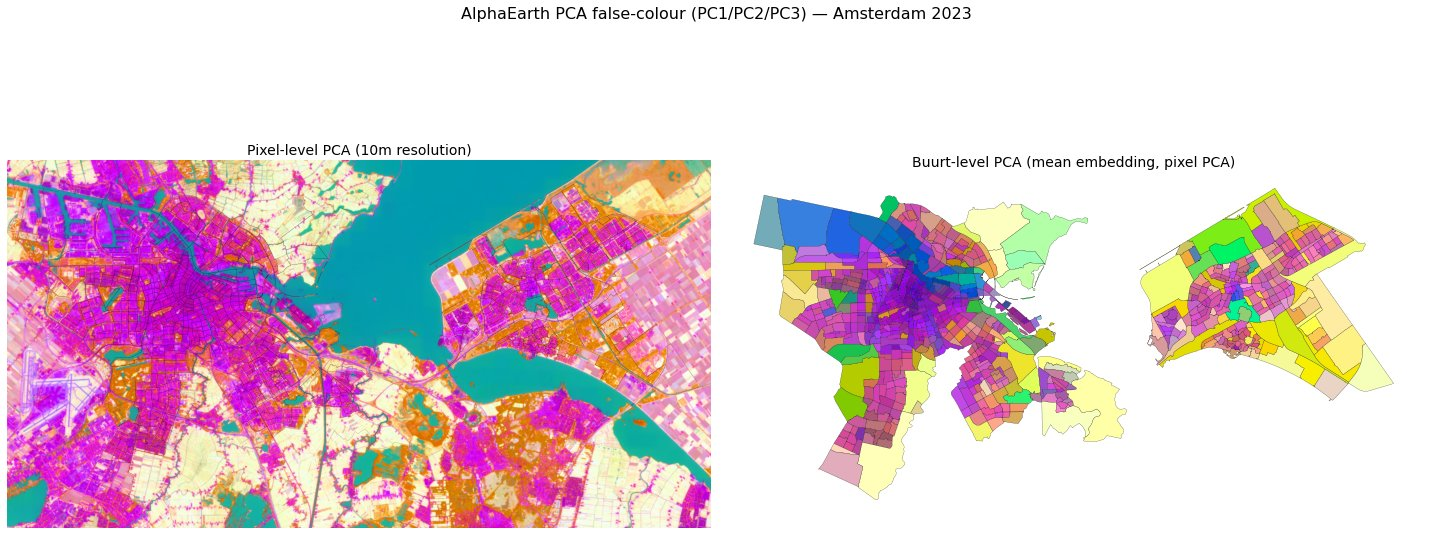

In [15]:
# --- Left panel: pixel-level PCA false-colour ---
# Read the full raster and reduce 64 bands to 3 PCs per pixel
with rasterio.open(GEOTIFF_FILE) as src:
    data = src.read()  # shape (64, height, width)
    extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

bands, h, w = data.shape
flat = data.reshape(bands, -1).T  # (n_pixels, 64)
del data  # free memory before fitting PCA
valid = np.all(np.isfinite(flat), axis=1)

pca_pixel = PCA(n_components=3)
pca_pixel.fit(flat[valid])
transformed = np.full((h * w, 3), np.nan)
transformed[valid] = pca_pixel.transform(flat[valid])
del flat, valid
rgb_pixel = transformed.reshape(h, w, 3)

# Normalise each channel to 0–1 (2–98th percentile stretch)
for ch in range(3):
    vmin, vmax = np.nanpercentile(rgb_pixel[:, :, ch], [2, 98])
    rgb_pixel[:, :, ch] = np.clip((rgb_pixel[:, :, ch] - vmin) / (vmax - vmin), 0, 1)
rgb_pixel = np.nan_to_num(rgb_pixel, nan=1.0)

# --- Right panel: buurt-level PCA false-colour ---
# Use the SAME PCA fitted on pixels so colours are directly comparable
embeddings_matrix = np.stack(alphaearth_df['mean_embedding'].values)
pcs = pca_pixel.transform(embeddings_matrix)

pcs_normed = np.zeros_like(pcs)
for ch in range(3):
    vmin, vmax = np.percentile(pcs[:, ch], [2, 98])
    pcs_normed[:, ch] = np.clip((pcs[:, ch] - vmin) / (vmax - vmin), 0, 1)

# Align geometries with embedding rows via an explicit row index on alphaearth_df,
# so we can pass colours to a single vectorised plot call.
plot_df = alphaearth_df[[JOIN_KEY]].copy()
plot_df['_row'] = np.arange(len(plot_df))
ams_buurten_rgb = ams_buurten.merge(plot_df, on=JOIN_KEY, how='inner').reset_index(drop=True)
rgb_array = pcs_normed[ams_buurten_rgb['_row'].to_numpy()]

# --- Plot side by side ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Left: pixel-level
ax1.imshow(rgb_pixel, extent=extent, origin='upper')
ams_buurten.boundary.plot(ax=ax1, linewidth=0.3, color='black', alpha=0.3)
ax1.set_title(f'Pixel-level PCA (10m resolution)', fontsize=14)
ax1.set_axis_off()

# Right: buurt-level (same PCA as pixel map).
# Single vectorised plot call — passing `color` as an (N, 3) array paints every polygon in one pass.
ams_buurten_rgb.plot(ax=ax2, color=rgb_array, edgecolor='black', linewidth=0.2)
ax2.set_title(f'Buurt-level PCA (mean embedding, pixel PCA)', fontsize=14)
ax2.set_axis_off()

fig.suptitle(f'AlphaEarth PCA false-colour (PC1/PC2/PC3) — Amsterdam {YEAR}', fontsize=16, y=0.95)
plt.tight_layout()

# Save to PDF in the outputs directory
output_path = os.path.join(outputs_dir, "9a-comparing_embeddings.png")
plt.savefig(output_path, bbox_inches="tight")
print(f"Saved embedding comparison map to {output_path}")

show_jpeg()

### Road-following resampling (to match the street-view sampling support)

The zonal statistics above aggregate **every** 10 m pixel inside a buurt — roads, but
also water, parks, fields and industrial roofs. The street-level branch instead samples
only along the **road network** (panoramas trace the roads), so its per-buurt embedding
is supported only by populated, road-adjacent locations. That difference could, on its
own, explain part of AlphaEarth's weaker fit.

To test this, we re-aggregate the **same** AlphaEarth raster over the **same** panorama
point locations the street-view branch uses (notebook 3), producing two extra variants:

- **`road_point`** — the single 10 m pixel under each panorama point. A pixel centred on
  the road is mostly tarmac (a near-constant signal), so this is a deliberately weak
  sanity baseline.
- **`road_buffer`** — the median of the pixels within `ROAD_BUFFER_M` (default 20 m) of
  each point, so the feature "looks outward" at the surrounding built form the way a
  panorama's field of view does. This is the informative comparison.

Each is then aggregated to buurt level with the **same** point→buurt spatial join and the
**same** per-buurt statistic as notebook 3, so the only thing differing from the
street-view model is the feature source (satellite pixel vs street-level CLIP). Results go
to their own pickles (the whole-buurt zonal pickle above is left untouched), and notebook
9b compares all variants side by side.

> **Requires the panorama H5** (notebooks 1–2). This is the only part of 9a that depends
> on the street-view branch; the whole-buurt zonal stats above are independent.

In [16]:
# ── Road-following resampling: configuration + helpers ───────────────────────
# The zonal stats above average EVERY 10 m pixel inside a buurt (roads, but also
# water, parks, fields, industrial roofs). The street-view branch instead samples
# only ON the road network — panoramas trace the roads — so its per-buurt embedding
# is supported only by populated, road-adjacent locations. To compare like with like
# (and to test whether AlphaEarth's weaker fit is partly a SAMPLING artefact rather
# than a sensor one) we re-aggregate the SAME raster over the SAME points the SVI
# branch uses (notebook 3's panorama locations), producing two extra variants:
#
#   road_point  : the single 10 m pixel under each panorama point. A pixel centred on
#                 the road is mostly tarmac — a near-constant signal — so this is a
#                 deliberately weak sanity baseline.
#   road_buffer : the median of the pixels within ROAD_BUFFER_M of each point, so the
#                 feature "looks outward" at the surrounding built form the way a
#                 panorama's field of view does. This is the informative comparison.
#
# Both then aggregate to buurt level with the SAME point->buurt spatial join and the
# SAME per-buurt statistic as notebook 3, so the ONLY thing differing from the SVI
# model is the feature source (satellite pixel vs street-level CLIP).
import h5py

ROAD_BUFFER_M = 20.0       # radius (m) over which pixels are pooled per point; tunable
WITHIN_STAT   = 'median'   # how pixels within one point's buffer are pooled (median, as elsewhere)
ROAD_VARIANTS = {'road_point': 0.0, 'road_buffer': ROAD_BUFFER_M}  # name -> radius (m); 0 = single pixel
ROAD_CACHE = {name: os.path.join(cache_dir, f'alphaearth_embeddings_{name}.pkl')
              for name in ROAD_VARIANTS}


def sample_road_variants(geotiff, lons, lats, variants, within_stat='median'):
    """Pool AlphaEarth pixels around each (lon, lat) point.

    For every variant, reduce the pixels within `radius_m` of each point to one 64-d
    vector using `within_stat`. A radius of 0 means the single pixel under the point.
    The raster is read once into memory and all variants share it.

    Distances are computed in metres via a local degrees->metres scaling at the AOI's
    mean latitude (accurate to <0.5% over a ~20 m window), so the circular buffer is
    correct even though the raster is in EPSG:4326 (where a pixel is ~10 m tall but
    only ~6 m wide at this latitude).

    Returns dict name -> (n_points, n_bands) float32 array; a row is NaN where no
    finite pixel fell in the buffer (point outside the raster, or over nodata).
    """
    reducer = {'median': np.nanmedian, 'mean': np.nanmean}[within_stat]
    with rasterio.open(geotiff) as src:
        data = src.read(out_dtype='float32')           # (bands, H, W); cast on read (single alloc)
        transform = src.transform
        H, W = src.height, src.width
    nb = data.shape[0]
    lons = np.asarray(lons, float); lats = np.asarray(lats, float)
    n = len(lons)

    m_per_deg_lat = 111_320.0
    m_per_deg_lon = 111_320.0 * np.cos(np.radians(float(np.mean(lats))))
    px_w, px_h = abs(transform.a), abs(transform.e)    # pixel size in degrees (north-up)

    inv = ~transform                                   # pixel (row, col) under each point
    cols, rows = inv * (lons, lats)
    cols = np.floor(cols).astype(int); rows = np.floor(rows).astype(int)

    results = {name: np.full((n, nb), np.nan, dtype='float32') for name in variants}
    in_raster = (rows >= 0) & (rows < H) & (cols >= 0) & (cols < W)

    for name, radius_m in variants.items():
        out = results[name]
        if radius_m <= 0:                              # single pixel under the point
            for i in np.nonzero(in_raster)[0]:
                px = data[:, rows[i], cols[i]]
                if np.all(np.isfinite(px)):
                    out[i] = px
            continue

        hw_x = int(np.ceil(radius_m / (m_per_deg_lon * px_w)))   # window half-width (cols)
        hw_y = int(np.ceil(radius_m / (m_per_deg_lat * px_h)))   # window half-width (rows)
        r2_m = radius_m * radius_m
        for i in np.nonzero(in_raster)[0]:
            r0, c0 = rows[i], cols[i]
            r1, r2 = max(0, r0 - hw_y), min(H, r0 + hw_y + 1)
            c1, c2 = max(0, c0 - hw_x), min(W, c0 + hw_x + 1)
            block = data[:, r1:r2, c1:c2]                        # (bands, h, w)
            cc, rr = np.meshgrid(np.arange(c1, c2), np.arange(r1, r2))
            lon_c = transform.c + (cc + 0.5) * transform.a       # pixel-centre lon
            lat_c = transform.f + (rr + 0.5) * transform.e       # pixel-centre lat
            dx = (lon_c - lons[i]) * m_per_deg_lon
            dy = (lat_c - lats[i]) * m_per_deg_lat
            mask = (dx * dx + dy * dy) <= r2_m                   # circular mask (h, w)
            if not mask.any():
                continue
            sel = block[:, mask]                                 # (bands, n_sel)
            sel = np.where(np.isfinite(sel), sel, np.nan)
            if np.isnan(sel).all():
                continue
            out[i] = reducer(sel, axis=1)
    return results


def per_buurt_embeddings(per_point, lons, lats, buurten_4326, aggregations):
    """Reduce per-point sampled vectors to per-buurt embeddings.

    Assigns each point to a buurt by point-in-polygon (the SAME join as notebook 3),
    drops points whose sampled vector is non-finite (outside raster / nodata), then
    aggregates the points in each buurt with each of `aggregations`. Returns a frame
    of one row per buurt with a `<agg>_embedding` column per aggregation — the same
    schema as the whole-buurt zonal pickle, so 9b can load any variant identically.
    """
    finite = np.isfinite(per_point).all(axis=1)
    pts = gpd.GeoDataFrame(
        {'_row': np.nonzero(finite)[0]},
        geometry=gpd.points_from_xy(np.asarray(lons)[finite], np.asarray(lats)[finite]),
        crs='EPSG:4326')
    joined = gpd.sjoin(pts, buurten_4326[[JOIN_KEY, 'geometry']], how='inner', predicate='within')
    reducers = {'mean': np.mean, 'median': np.median, 'min': np.min, 'max': np.max}
    out_rows = []
    for code, grp in joined.groupby(JOIN_KEY):
        vecs = per_point[grp['_row'].to_numpy()]                 # (k, n_bands)
        row = {JOIN_KEY: code}
        for agg in aggregations:
            row[f'{agg}_embedding'] = reducers[agg](vecs, axis=0)
        out_rows.append(row)
    return pd.DataFrame(out_rows)

In [17]:
# Build (and cache) the road-following variants. This is the ONLY part of 9a that
# depends on the street-view branch having been run: it reuses notebook 3's panorama
# point locations (from the H5). The whole-buurt zonal stats above do not need it.
if all(os.path.exists(p) for p in ROAD_CACHE.values()):
    print("Road-sampled variants already cached — delete a pickle to recompute:")
    for name, p in ROAD_CACHE.items():
        print(f"  {name:11s} {p}")
elif not os.path.exists(h5_filename):
    print(f"H5 not found at {h5_filename}.")
    print("Run notebooks 1-2 (panorama download + embeddings) first to build the")
    print("road-following variants. Skipping them; the whole-buurt zonal stats above")
    print("are independent of the street-view branch and are unaffected.")
else:
    assert os.path.exists(GEOTIFF_FILE), (
        f"Uncompressed GeoTIFF not found at {GEOTIFF_FILE} — run the decompress cell above first."
    )
    # The exact same point locations the SVI per-buurt embeddings are built from (notebook 3).
    with h5py.File(h5_filename, "r") as f:
        pt_lat = f["latitude"][:]
        pt_lon = f["longitude"][:]
    print(f"Sampling the AlphaEarth raster at {len(pt_lat)} panorama point locations")
    print(f"(variants: {dict(ROAD_VARIANTS)} m; within-buffer statistic: {WITHIN_STAT})...")

    t0 = time.time()
    per_point = sample_road_variants(GEOTIFF_FILE, pt_lon, pt_lat, ROAD_VARIANTS,
                                     within_stat=WITHIN_STAT)
    print(f"Pixel sampling done ({time.time() - t0:.0f}s). Aggregating to buurt level")
    print("(same point->buurt spatial join + per-buurt statistic as notebook 3)...")

    for name in ROAD_VARIANTS:
        n_finite = int(np.isfinite(per_point[name]).all(axis=1).sum())
        df = per_buurt_embeddings(per_point[name], pt_lon, pt_lat, ams_buurten, AGGREGATIONS)
        df.to_pickle(ROAD_CACHE[name])
        print(f"  {name:11s}: {n_finite}/{len(pt_lat)} points sampled "
              f"-> {len(df)} buurten -> saved {ROAD_CACHE[name]}")

Road-sampled variants already cached — delete a pickle to recompute:
  road_point  ../data/processed/per_buurt_embedding_summaries/alphaearth_embeddings_road_point.pkl
  road_buffer ../data/processed/per_buurt_embedding_summaries/alphaearth_embeddings_road_buffer.pkl


### Visualise: road-sampled points vs buurt aggregate

The analogue of the pixel-vs-buurt PCA figure above, but for the road-following sample.
**Left**: the AlphaEarth embedding sampled at each panorama point (the street-view sampling
support), as PCA false-colour points. **Right**: the per-buurt aggregate of those points (the
features the `road_buffer` model actually sees). Both panels use a single PCA — the pixel PCA
from the figure above when it is in memory — so the colours are comparable both between the two
panels and against that earlier figure.

Saved road-sampled embedding map to ../outputs/9a-roadsampled_embeddings.png


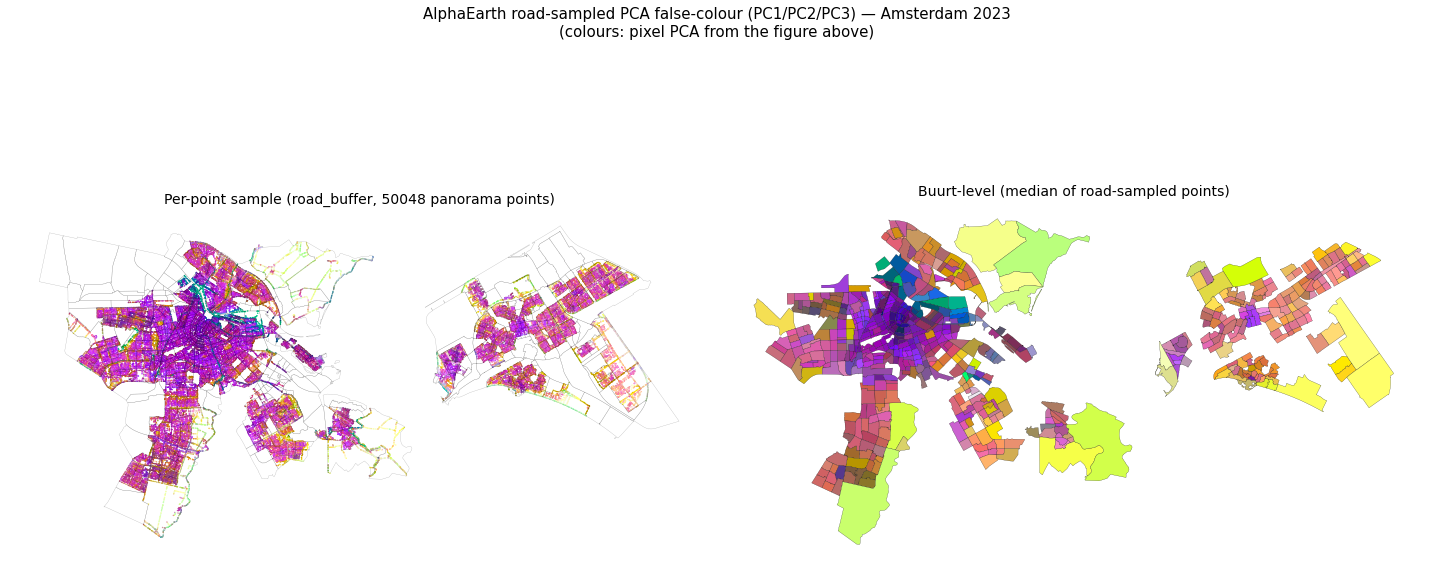

In [18]:
# Visualise the road-following sample, mirroring the pixel-vs-buurt figure above:
#   LEFT  — the AlphaEarth embedding sampled at each panorama point (the street-view
#           sampling support), as PCA false-colour points.
#   RIGHT — the per-buurt aggregate of those points (what the road_buffer model sees).
# Both use ONE PCA so the colours are directly comparable; we reuse the pixel PCA from
# the figure above where it exists, so this figure is also comparable to that one.
from sklearn.decomposition import PCA

ROAD_VIZ_VARIANT = 'road_buffer'   # which road variant to visualise
ROAD_VIZ_AGG     = 'median'        # buurt-level aggregation shown on the right

if not os.path.exists(ROAD_CACHE[ROAD_VIZ_VARIANT]):
    print(f"{ROAD_CACHE[ROAD_VIZ_VARIANT]} not found — run the road-sampling cell above first.")
else:
    # Per-point vectors + coordinates: reuse them from the sampling cell if still in
    # memory, otherwise recompute just this variant (needs the H5 + uncompressed GeoTIFF).
    if 'per_point' in globals() and ROAD_VIZ_VARIANT in per_point and 'pt_lon' in globals():
        pp, plon, plat = per_point[ROAD_VIZ_VARIANT], pt_lon, pt_lat
    elif os.path.exists(h5_filename) and os.path.exists(GEOTIFF_FILE):
        with h5py.File(h5_filename, "r") as f:
            plat, plon = f["latitude"][:], f["longitude"][:]
        pp = sample_road_variants(GEOTIFF_FILE, plon, plat,
                                  {ROAD_VIZ_VARIANT: ROAD_VARIANTS[ROAD_VIZ_VARIANT]},
                                  within_stat=WITHIN_STAT)[ROAD_VIZ_VARIANT]
    else:
        pp = plon = plat = None
        print("Per-point sampling unavailable (need the H5 + uncompressed GeoTIFF);")
        print("showing the buurt aggregate only.")

    # Buurt-level vectors (always available from the cached pickle).
    buurt_df = pd.read_pickle(ROAD_CACHE[ROAD_VIZ_VARIANT])
    buurt_vecs = np.stack(buurt_df[f'{ROAD_VIZ_AGG}_embedding'].values)

    # One PCA for both panels — reuse the pixel PCA from the figure above if present.
    if 'pca_pixel' in globals():
        pca, pca_src = pca_pixel, "pixel PCA from the figure above"
    else:
        fit_on = pp[np.isfinite(pp).all(axis=1)] if pp is not None else buurt_vecs
        pca, pca_src = PCA(n_components=3).fit(fit_on), "PCA fit on the road-sampled points"

    def _to_rgb(vectors, transformer):
        """Project to 3 PCs and stretch each channel to [0, 1] on its 2-98th percentiles."""
        pcs = transformer.transform(vectors)
        rgb = np.zeros_like(pcs)
        for ch in range(3):
            vmin, vmax = np.nanpercentile(pcs[:, ch], [2, 98])
            rgb[:, ch] = np.clip((pcs[:, ch] - vmin) / (vmax - vmin), 0, 1)
        return rgb

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

    # LEFT: per-point sample
    ams_buurten.boundary.plot(ax=ax1, linewidth=0.3, color="black", alpha=0.3)
    if pp is not None:
        finite = np.isfinite(pp).all(axis=1)
        ax1.scatter(np.asarray(plon)[finite], np.asarray(plat)[finite],
                    c=_to_rgb(pp[finite], pca), s=2, linewidths=0)
        ax1.set_title(f"Per-point sample ({ROAD_VIZ_VARIANT}, {int(finite.sum())} panorama points)",
                      fontsize=14)
    else:
        ax1.set_title("Per-point sample (unavailable)", fontsize=14)
    ax1.set_axis_off()

    # RIGHT: buurt aggregate (same PCA as the left panel)
    buurt_rgb = _to_rgb(buurt_vecs, pca)
    plot_df = buurt_df[[JOIN_KEY]].copy()
    plot_df['_row'] = np.arange(len(plot_df))
    bplot = ams_buurten.merge(plot_df, on=JOIN_KEY, how='inner').reset_index(drop=True)
    bplot.plot(ax=ax2, color=buurt_rgb[bplot['_row'].to_numpy()], edgecolor="black", linewidth=0.2)
    ax2.set_title(f"Buurt-level ({ROAD_VIZ_AGG} of road-sampled points)", fontsize=14)
    ax2.set_axis_off()

    fig.suptitle(f"AlphaEarth road-sampled PCA false-colour (PC1/PC2/PC3) — Amsterdam {YEAR}\n"
                 f"(colours: {pca_src})", fontsize=15, y=0.99)
    plt.tight_layout()

    out = os.path.join(outputs_dir, "9a-roadsampled_embeddings.png")
    plt.savefig(out, bbox_inches="tight")
    print(f"Saved road-sampled embedding map to {out}")
    plt.show()

### Clean up: remove uncompressed GeoTIFF

Delete the temporary uncompressed `.tif` file now that all rasterio processing
is complete. The gzipped version is kept on disk.

In [19]:
# Remove the uncompressed GeoTIFF to free disk space.
# Only delete if the gzipped version exists (safety check).
if os.path.exists(GEOTIFF_FILE) and os.path.exists(GEOTIFF_FILE_GZ):
    os.remove(GEOTIFF_FILE)
    print(f"Removed uncompressed {GEOTIFF_FILE}")
    print(f"Keeping compressed {GEOTIFF_FILE_GZ}")
elif os.path.exists(GEOTIFF_FILE):
    print(f"Warning: gzipped version not found — keeping uncompressed file")
else:
    print(f"No uncompressed file to clean up")

Removed uncompressed ../data/processed/alphaearth_amsterdam_2023.tif
Keeping compressed ../data/processed/alphaearth_amsterdam_2023.tif.gz
